# Build basic 2-Layer MLP to solve the xor-Problem

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs #for data generatio
from sklearn.model_selection import train_test_split #for test set generation
import torch
import torch.nn as nn


In [9]:
X, y = make_blobs(n_samples=200, n_features=2, cluster_std=.1
                  ,centers= [(1,1), (1,0), (0,0),(0,1)])

In [10]:
#make blobs into binary problem
y[y==2]=0
y[y==3]=1

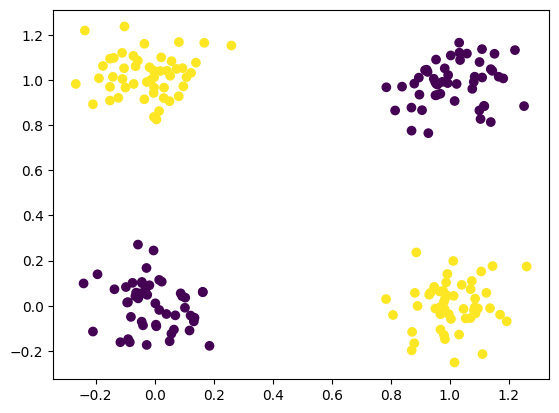

In [11]:
plt.scatter(X[:,0],X[:,1],c=y)

## Steps:
* build train and test sets
* write MLP class in Pytorch with two layers with adjustable number of perceptrons
* use nn.linear and nn.Sigmoid() units
* train your model
* test your model

Prepare Training and Test Data


In [14]:
#split in train and test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#np->torch
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [15]:
#have look
y_train

tensor([0., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0.,
        1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0.,
        0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
        1., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1.,
        1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
        1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1.,
        0., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        0., 1., 1., 0., 0., 1., 0., 0.])

Build Perceptrons

In [16]:
# Fine Declaration - Maybe nice to make
class MLP2Simple(torch.nn.Module):
    def __init__(self, hiddensize_1, hiddensize_2):
        super().__init__()
        self.fc1 = torch.nn.Linear()
        self.sigmoid1 = torch.nn.Sigmoid()

        self.fc2 = torch.nn.Linear()
        self.sigmoid2 = torch.nn.Sigmoid()

        self.fc3 = torch.nn.Linear()




    def forward(self, x):



Get Instance of Model

In [21]:
#get instance of perceptron model
model = MLP()

#define loss function
criterion = torch.nn.CrossEntropyLoss()

#define optimizer -> SGD with learning rate lr
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)


In [22]:
#run test data theogh untrained model
model.eval() #set to eval mode
model(x_test)

tensor([[0.4487],
        [0.4560],
        [0.5356],
        [0.4596],
        [0.4402],
        [0.4598],
        [0.5262],
        [0.5301],
        [0.5386],
        [0.5272],
        [0.4885],
        [0.4869],
        [0.5411],
        [0.5314],
        [0.5323],
        [0.5346],
        [0.4589],
        [0.4858],
        [0.4864],
        [0.4612],
        [0.5352],
        [0.5457],
        [0.4885],
        [0.5335],
        [0.5350],
        [0.4962],
        [0.5323],
        [0.4488],
        [0.5282],
        [0.4873],
        [0.4795],
        [0.5359],
        [0.5275],
        [0.5282],
        [0.5335],
        [0.4548],
        [0.4843],
        [0.5337],
        [0.5385],
        [0.5277],
        [0.5370],
        [0.5356],
        [0.4561],
        [0.5368],
        [0.5227],
        [0.5310],
        [0.4876],
        [0.5168],
        [0.4645],
        [0.4917],
        [0.5271],
        [0.5364],
        [0.5420],
        [0.4603],
        [0.4827],
        [0

In [23]:
model.train() #set to train mode
epoch = 50
for epoch in range(epoch):
    optimizer.zero_grad()
    # Forward pass
    y_pred = model(x_train)
    # Compute Loss
    loss = criterion(y_pred.squeeze(), y_train)

    print('Epoch {}: train loss: {}'.format(epoch, loss.item()))
    # Backward pass
    loss.backward()
    #make gradient update
    optimizer.step()

Epoch 0: train loss: 366.79681396484375
Epoch 1: train loss: 366.72198486328125
Epoch 2: train loss: 366.644775390625
Epoch 3: train loss: 366.57073974609375
Epoch 4: train loss: 366.5061950683594
Epoch 5: train loss: 366.44805908203125
Epoch 6: train loss: 366.3927307128906
Epoch 7: train loss: 366.33587646484375
Epoch 8: train loss: 366.27716064453125
Epoch 9: train loss: 366.2164611816406
Epoch 10: train loss: 366.1523132324219
Epoch 11: train loss: 366.08428955078125
Epoch 12: train loss: 366.0130310058594
Epoch 13: train loss: 365.9386901855469
Epoch 14: train loss: 365.860107421875
Epoch 15: train loss: 365.778076171875
Epoch 16: train loss: 365.6920166015625
Epoch 17: train loss: 365.6016540527344
Epoch 18: train loss: 365.50628662109375
Epoch 19: train loss: 365.4056091308594
Epoch 20: train loss: 365.29962158203125
Epoch 21: train loss: 365.1900634765625
Epoch 22: train loss: 365.0763244628906
Epoch 23: train loss: 364.96551513671875
Epoch 24: train loss: 364.8551025390625
Epo